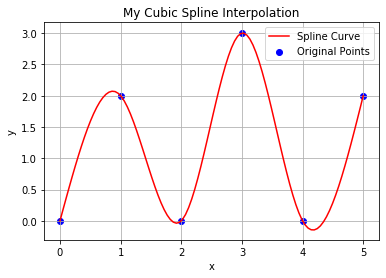

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y_vals = np.array([0, 2, 0, 3, 0, 2], dtype=float)

def build_system(x, y):
    n = len(x)

    h = np.diff(x)

    lower = np.zeros(n - 2)
    main = np.zeros(n - 2)
    upper = np.zeros(n - 2)
    rhs = np.zeros(n - 2)

    for i in range(1, n - 1):
        lower[i - 1] = h[i - 1]
        main[i - 1] = 2 * (h[i - 1] + h[i])
        upper[i - 1] = h[i]

        rhs[i - 1] = 6 * (
            (y[i + 1] - y[i]) / h[i] -
            (y[i] - y[i - 1]) / h[i - 1]
        )
    
    return lower, main, upper, rhs

def solve_tridiagonal(a, b, c, d):
    n = len(b)

    for i in range(1, n):
        factor = a[i - 1] / b[i - 1]
        b[i] = b[i] - factor * c[i - 1]
        d[i] = d[i] - factor * d[i - 1]

    solution = np.zeros(n)
    solution[-1] = d[-1] / b[-1]
    
    for i in range(n - 2, -1, -1):
        solution[i] = (d[i] - c[i] * solution[i + 1]) / b[i]
    
    return solution

a, b, c, d = build_system(x_vals, y_vals)

M_inner = solve_tridiagonal(a, b, c, d)

M_vals = np.concatenate(([0], M_inner, [0]))

def spline_value(x_data, y_data, M, x_query):
    n = len(x_data)
    h = np.diff(x_data)

    idx = np.searchsorted(x_data, x_query) - 1
    idx = np.clip(idx, 0, n - 2)
    
    hi = h[idx]

    left = x_query - x_data[idx]
    right = x_data[idx + 1] - x_query

    result = (
        (M[idx] / (6 * hi)) * right**3 +
        (M[idx + 1] / (6 * hi)) * left**3 +
        (y_data[idx] / hi - (M[idx] * hi) / 6) * right +
        (y_data[idx + 1] / hi - (M[idx + 1] * hi) / 6) * left
    )
    
    return result

x_smooth = np.linspace(0, 5, 100)
y_smooth = spline_value(x_vals, y_vals, M_vals, x_smooth)

plt.scatter(x_vals, y_vals, color='blue', label='Original Points')
plt.plot(x_smooth, y_smooth, color='red', label='Spline Curve')

plt.title("My Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.show(block=True)